### Customer retention is a key challenge in the banking industry
Focusing on predicting customer churn—whether a customer is likely to leave the bank—using demographic, account, and behavioral information.

Participants are tasked with building a binary classification model to predict the target variable Exited, where:

1 = Customer churned (left the bank)

0 = Customer remained with the bank

### Evaluation
Submissions will be evaluated using "Accuracy".

Accuracy measures the proportion of correctly classified customers and is calculated as:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

#### import library

In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score ,confusion_matrix


In [212]:
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cpu


In [213]:
# Load the dataset
data = pd.read_csv("train.csv")
test_data = pd.read_csv("test_without_labels.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,3888,15769110,Stehle,653,France,Female,46,5,0.00,2,1,0,49707.85,0
1,6618,15700826,Ko,678,Germany,Female,54,1,123699.28,2,0,1,105221.76,0
2,6622,15710365,Thomson,646,France,Male,50,0,104129.24,2,1,0,181794.86,1
3,6627,15619932,Lombardi,847,France,Male,66,7,123760.68,1,0,1,53157.16,0
4,8353,15641413,Crawford,587,Germany,Female,49,7,155393.98,2,1,0,13308.20,1


In [214]:
# shape of the dataset
print(f"Shape of the dataset: {data.shape}")
print(f"Shape of the test dataset: {test_data.shape}")

Shape of the dataset: (7000, 14)
Shape of the test dataset: (3000, 13)


### preprocessing the data

In [215]:
# drop the 'RowNumber', 'Surname' column as it is not useful for prediction
data = data.drop(['RowNumber', 'Surname'], axis=1)
test_data_pre = test_data.drop(['RowNumber', 'Surname'], axis=1)

In [216]:
# one-hot encode categorical variables
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True, dtype=int)
test_data_pre = pd.get_dummies(test_data_pre, columns=['Geography', 'Gender'], drop_first=True, dtype=int)
data.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,15769110,653,46,5,0.00,2,1,0,49707.85,0,0,0,0
1,15700826,678,54,1,123699.28,2,0,1,105221.76,0,1,0,0
2,15710365,646,50,0,104129.24,2,1,0,181794.86,1,0,0,1
3,15619932,847,66,7,123760.68,1,0,1,53157.16,0,0,0,1
4,15641413,587,49,7,155393.98,2,1,0,13308.20,1,1,0,0


In [217]:
# correlation matrix
correlation_matrix = data.corr()
considering_correlation = correlation_matrix['Exited'].sort_values(ascending=False)
considering_correlation

Exited               1.000000
Age                  0.375804
Geography_Germany    0.320158
Balance              0.237334
EstimatedSalary      0.018328
HasCrCard            0.006205
CustomerId          -0.005307
Tenure              -0.063052
Gender_Male         -0.093804
Geography_Spain     -0.097803
CreditScore         -0.108203
NumOfProducts       -0.190115
IsActiveMember      -0.404305
Name: Exited, dtype: float64

we see that 'HasCrCard' and 'CustomerId' are not useful for prediction, so we will drop them also.

In [218]:
# drop the 'HasCrCard' and 'CustomerId' columns as they are not useful for prediction
# drop HasCrCard and CustomerId if they exist (avoid empty-string bug)
drop_cols = [c for c in ['HasCrCard', 'CustomerId'] if c in data.columns]
if drop_cols:
    data = data.drop(drop_cols, axis=1)
    # drop from test dummies only if present
    test_drop = [c for c in drop_cols if c in test_data_pre.columns]
    if test_drop:
        test_data_pre = test_data_pre.drop(test_drop, axis=1)
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,653,46,5,0.00,2,0,49707.85,0,0,0,0
1,678,54,1,123699.28,2,1,105221.76,0,1,0,0
2,646,50,0,104129.24,2,0,181794.86,1,0,0,1
3,847,66,7,123760.68,1,1,53157.16,0,0,0,1
4,587,49,7,155393.98,2,0,13308.20,1,1,0,0


In [219]:
# split the dataset into training and validation sets
feature_cols = data.drop('Exited', axis=1).columns
# Ensure test features align with training features (add missing columns and order)
test_data_pre = test_data_pre.reindex(columns=feature_cols, fill_value=0)
X = data[feature_cols].values
y = data['Exited'].values

# scale the features using Min-Max scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
test_data_pre = scaler.transform(test_data_pre.values)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")


Train shape: (4900, 10), Validation shape: (2100, 10)


### Building a predictive model (NN with Torch)

In [220]:
# initialize the features and target variable to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(test_data_pre, dtype=torch.float32).to(device)
X_train_tensor.shape, X_val_tensor.shape, y_train_tensor.shape, y_val_tensor.shape

(torch.Size([4900, 10]),
 torch.Size([2100, 10]),
 torch.Size([4900]),
 torch.Size([2100]))

In [221]:
# Custom Dataset class for our bank customers data
class BankCustomersDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
class TestDataset(Dataset):
    def __init__(self, X):
        self.X = X
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

test_dataset = TestDataset(X_test_tensor)
train_dataset = BankCustomersDataset(X_train_tensor, y_train_tensor)
val_dataset = BankCustomersDataset(X_val_tensor, y_val_tensor)
print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")
print(f"Sample train data: {train_dataset[0]}")
print(f"Sample test data: {test_dataset[0]}")

Train samples: 4900, Validation samples: 2100
Sample train data: (tensor([0.4000, 0.2568, 0.3000, 0.0000, 0.0000, 1.0000, 0.8984, 0.0000, 0.0000,
        1.0000]), tensor(0.))
Sample test data: tensor([0.6480, 0.0000, 0.7000, 0.0000, 0.3333, 1.0000, 0.2787, 0.0000, 0.0000,
        1.0000])


In [222]:
# data loaders
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)
for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}:")
    print(f"X_batch shape: {X_batch.shape}")
    print(f"y_batch shape: {y_batch.shape}")
    break

Batch 1:
X_batch shape: torch.Size([32, 10])
y_batch shape: torch.Size([32])


In [ ]:
# building NN class
class BankCustomerNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            # nn.Linear(32, 16),
            # nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()  
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


In [224]:
# training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device=device):
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    val_precision_history = []
    val_recall_history = []
    val_f1_history = []
    val_auc_history = []

    best_f1 = -1.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_loss_history.append(train_loss)

        model.eval()
        val_running_loss = 0.0
        val_probs = []
        val_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)
                val_running_loss += loss.item()
                val_probs.extend(outputs.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)
        val_loss_history.append(val_loss)

        val_probs = np.array(val_probs)
        val_labels = np.array(val_labels)
        val_preds = (val_probs >= 0.5).astype(int)

        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        val_auc = roc_auc_score(val_labels, val_probs)

        val_acc_history.append(val_acc)
        val_precision_history.append(val_precision)
        val_recall_history.append(val_recall)
        val_f1_history.append(val_f1)
        val_auc_history.append(val_auc)

        # save best model by validation F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), 'best_model.pt')

        print(
            f"Epoch [{epoch + 1}/{epochs}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    return {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'val_acc': val_acc_history,
        'val_precision': val_precision_history,
        'val_recall': val_recall_history,
        'val_f1': val_f1_history,
        'val_auc': val_auc_history,
    }


Training the model...
Epoch [1/100] train_loss=0.4929 val_loss=0.4141 val_acc=0.8190
Epoch [2/100] train_loss=0.3599 val_loss=0.3032 val_acc=0.8790
Epoch [3/100] train_loss=0.2820 val_loss=0.2477 val_acc=0.9143
Epoch [4/100] train_loss=0.2451 val_loss=0.2212 val_acc=0.9167
Epoch [5/100] train_loss=0.2289 val_loss=0.2111 val_acc=0.9210
Epoch [6/100] train_loss=0.2198 val_loss=0.1955 val_acc=0.9310
Epoch [7/100] train_loss=0.2076 val_loss=0.1920 val_acc=0.9314
Epoch [8/100] train_loss=0.2015 val_loss=0.1843 val_acc=0.9324
Epoch [9/100] train_loss=0.1960 val_loss=0.1795 val_acc=0.9314
Epoch [10/100] train_loss=0.1909 val_loss=0.1749 val_acc=0.9338
Epoch [11/100] train_loss=0.1860 val_loss=0.1701 val_acc=0.9367
Epoch [12/100] train_loss=0.1791 val_loss=0.1670 val_acc=0.9352
Epoch [13/100] train_loss=0.1741 val_loss=0.1600 val_acc=0.9367
Epoch [14/100] train_loss=0.1735 val_loss=0.1547 val_acc=0.9390
Epoch [15/100] train_loss=0.1627 val_loss=0.1505 val_acc=0.9390
Epoch [16/100] train_loss=0

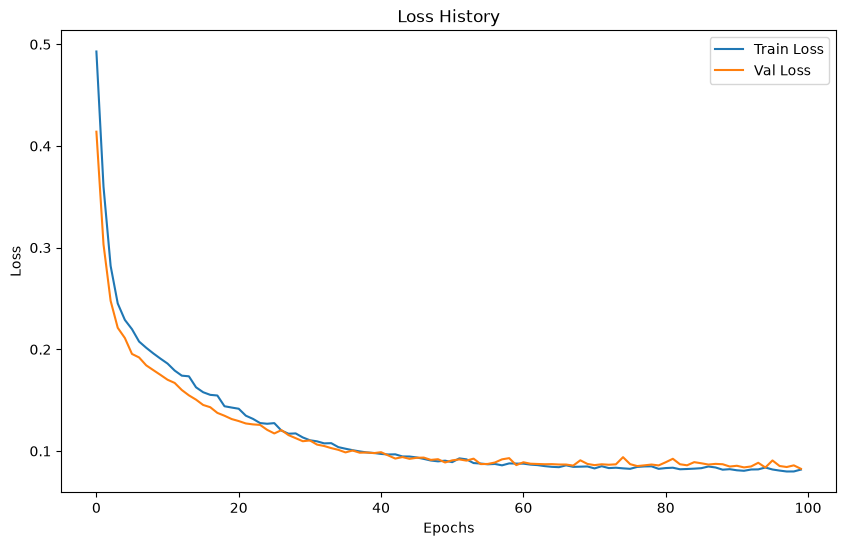

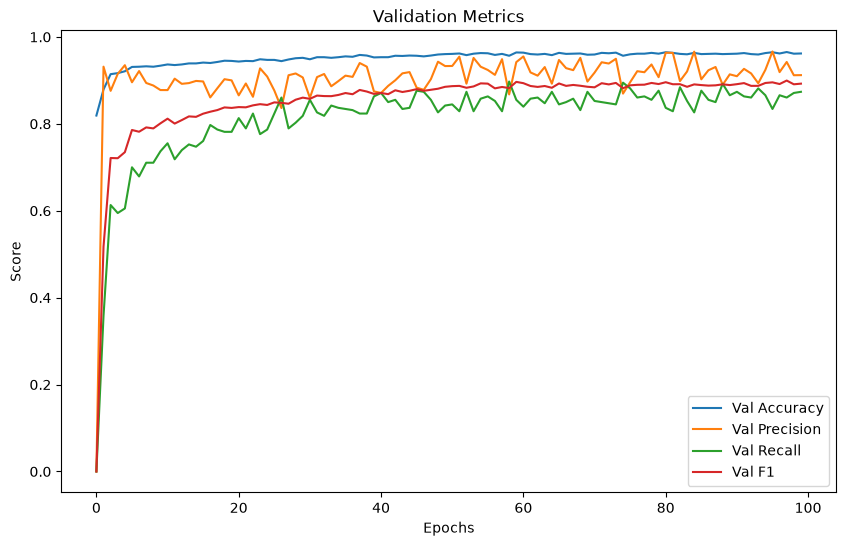

In [ ]:
model = BankCustomerNN(input_dim=X_train_tensor.shape[1]).to(device)

# selecting the optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss()
print("Training the model...")
metrics = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=100,
)
# Visualizing the loss history
plt.plot(metrics['train_loss'], label="Train Loss")
plt.plot(metrics['val_loss'], label="Val Loss")
plt.title("Loss History")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualizing the validation metrics
plt.plot(metrics['val_acc'], label="Val Accuracy")
plt.plot(metrics['val_precision'], label="Val Precision")
plt.plot(metrics['val_recall'], label="Val Recall")
plt.plot(metrics['val_f1'], label="Val F1")
plt.title("Validation Metrics")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.show()


In [ ]:
# Evaluate the model on the validation data
model.eval()
with torch.no_grad():
    probs = model(X_val_tensor)
    y_pred_class = (probs >= 0.5).int()
    
# Accuracy
accuracy = accuracy_score(y_val_tensor.cpu(), y_pred_class.cpu())
classification = classification_report(y_val_tensor.cpu(), y_pred_class.cpu())

# print the results
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Classification Report:\n{classification}")


Validation Accuracy: 0.9619
Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98      1720
         1.0       0.91      0.87      0.89       380

    accuracy                           0.96      2100
   macro avg       0.94      0.93      0.93      2100
weighted avg       0.96      0.96      0.96      2100



### Testing the model

In [ ]:
# testing the model and saving the predictions to a CSV file
# load best saved model if present
model.eval()
preds = []
with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        probs = model(xb)
        preds.extend((probs >= 0.5).int().cpu().numpy())

# build submission
submission = pd.DataFrame({'id': np.arange(len(test_data)), 'Exited': preds})
submission.to_csv("submission.csv", index=False)
print(f"Submission saved to submission.csv")


Submission saved to submission.csv
